Cost Hamiltonian: SparsePauliOp(['IIII', 'IIIZ', 'IIZI', 'IZII', 'ZIII', 'IIZZ', 'IZIZ', 'ZIIZ', 'YYYY', 'XXYY', 'YYXX', 'XXXX', 'IZZI', 'ZIZI', 'ZZII'],
              coeffs=[-0.81280876+0.j,  0.17110568+0.j, -0.22250985+0.j,  0.17110568+0.j,
 -0.22250985+0.j,  0.12051037+0.j,  0.16859357+0.j,  0.16584097+0.j,
  0.0453306 +0.j,  0.0453306 +0.j,  0.0453306 +0.j,  0.0453306 +0.j,
  0.16584097+0.j,  0.17432084+0.j,  0.12051037+0.j])
Commutator Hamiltonian: SparsePauliOp(['YIII', 'YIIZ', 'ZYYY', 'ZYXX', 'YIZI', 'YZII', 'IYII', 'IYIZ', 'YZYY', 'YZXX', 'IYZI', 'ZYII', 'IIYI', 'IIYZ', 'YYZY', 'XXZY', 'IZYI', 'ZIYI', 'IIIY', 'IIZY', 'IZIY', 'ZIIY', 'YYYZ', 'XXYZ'],
              coeffs=[ 0.12015532+0.j, -0.08955412+0.j,  0.02447852+0.j,  0.02447852+0.j,
 -0.09413326+0.j, -0.0650756 +0.j, -0.09239707+0.j, -0.09104053+0.j,
  0.02447852+0.j,  0.02447852+0.j, -0.08955412+0.j, -0.0650756 +0.j,
  0.12015532+0.j, -0.0650756 +0.j,  0.02447852+0.j,  0.02447852+0.j,
 -0.08955412+0.j, -0.09413326+0.j, -

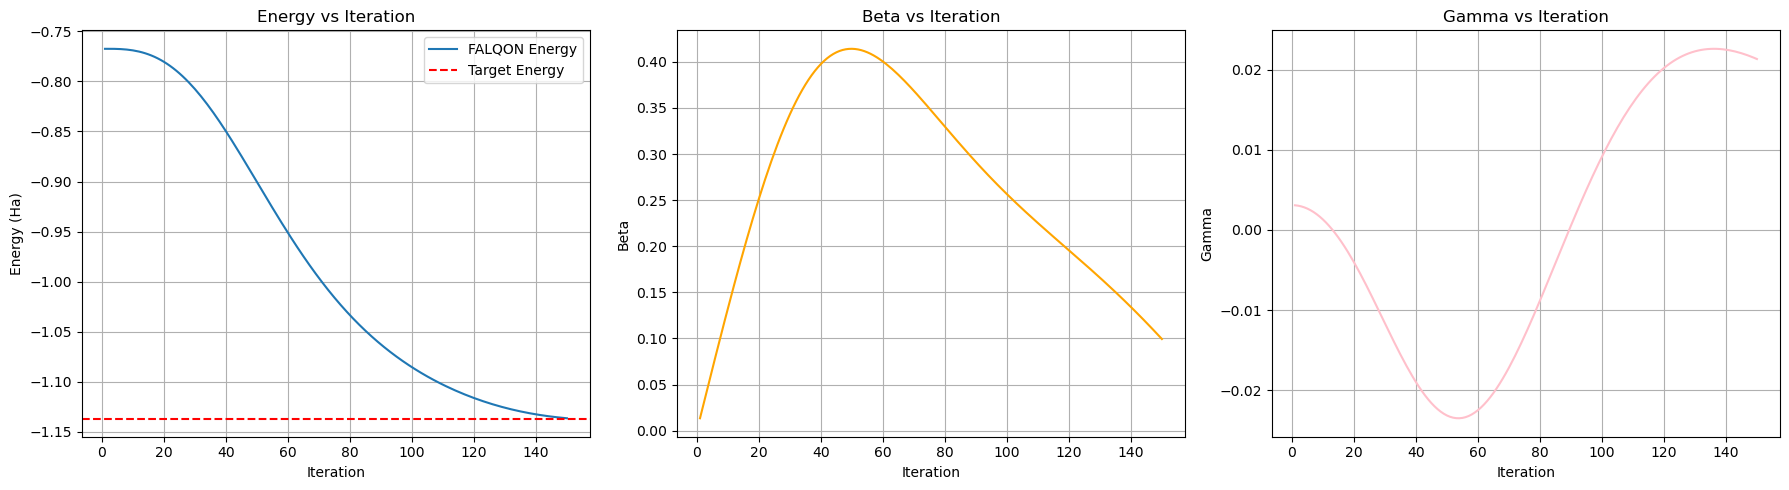

In [45]:
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.quantum_info import SparsePauliOp, Pauli
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import ParityMapper
from qiskit_nature.units import DistanceUnit
import numpy as np
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit.circuit import QuantumCircuit
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.quantum_info import SparsePauliOp
from qiskit.synthesis.evolution import SuzukiTrotter
from qiskit import transpile
from qiskit.transpiler import CouplingMap
from qiskit.transpiler import CouplingMap
import matplotlib.pyplot as plt
import numpy as np


n_qubits = 4
driver = PySCFDriver(
    atom="H 0 0 0; H 0 0 0.742",
    basis="sto3g",
    charge=0,
    spin=0,
    unit=DistanceUnit.ANGSTROM,
)

molecule = driver.run()
mapper = JordanWignerMapper()
cost_h = mapper.map(molecule.hamiltonian.second_q_op())

print("Cost Hamiltonian:", cost_h)
o_driver_h =SparsePauliOp.from_list([
    ("XIII", -1.0),
    ("IXII", -1.0),
    ("IIXI", -1.0),
    ("IIIX", -1.0),
])


driver_scaling = 0.27
driver_h = SparsePauliOp.from_list([
    ("XIII", -1.0*driver_scaling),
    ("IXII", -1.0*driver_scaling),
    ("IIXI", -1.0*driver_scaling),
    ("IIIX", -1.0*driver_scaling),
])




def build_commutator(op_a: SparsePauliOp, op_b: SparsePauliOp) -> SparsePauliOp:
    ab = op_a @ op_b
    ba = op_b @ op_a
    comm_pre= ab - ba
    comm = comm_pre*1j
    return comm.simplify()

def build_commutator2(op_a: SparsePauliOp, op_b: SparsePauliOp) -> SparsePauliOp:
    ab = op_a @ op_b
    ba = op_b @ op_a
    comm= ab - ba
    return comm.simplify()



comm_h=build_commutator(driver_h, cost_h)

comm_h2 = build_commutator(cost_h, comm_h)
comm_h3 = build_commutator(cost_h, comm_h2)
a=0.2
b=0.2
h_cd = a*comm_h+b*comm_h3


print("Commutator Hamiltonian:", comm_h)

def falqon_layer(qc,cost_h,driver_h,beta_k,h_cd,gamma_k,delta_t):
    #synth = SuzukiTrotter(reps=1)   ,synthesis=synth
    U_c= PauliEvolutionGate(cost_h,delta_t)
    U_d= PauliEvolutionGate(beta_k*driver_h,delta_t)
    U_cd = PauliEvolutionGate(gamma_k*h_cd, delta_t)

    qc.append(U_c, range(qc.num_qubits))
    qc.append(U_d, range(qc.num_qubits))
    qc.append(U_cd, range(qc.num_qubits))



E_set =-1.13728383

def main_loop(qc,cost_h,driver_h,comm_h,delta_t,beta_0,gamma_0,n_steps):
    beta =[beta_0]
    gamma = [gamma_0]
    energies=[]
    H =[]
    
    state = Statevector.from_label("+" * n_qubits)
    for i in range(n_steps):

        
        qc_layer = QuantumCircuit(n_qubits)
        '''
        H=cost_h+beta[i]*driver_h


        h_cd = build_commutator(H, driver_h)
        print("h_cd:", h_cd)
       
        
        '''
        comm_h2 = build_commutator(cost_h, h_cd)
        falqon_layer(qc_layer,cost_h,driver_h,beta[i],h_cd,gamma[i],delta_t)
        qc.compose(qc_layer, inplace=True)
        state = state.evolve(qc_layer) 

        next_beta =-1*state.expectation_value(comm_h).real
        beta.append(next_beta)

        next_gamma =1*state.expectation_value(comm_h2).real
        gamma.append(next_gamma)
        
        energy = state.expectation_value(cost_h).real
        energies.append(energy)
        print(f"第{i + 1}步：能量 = {energy:.8f} Ha| β_{i} = {beta[i]:+.6f} | γ_{i} = {gamma[i]:+.6f}")


        if i >= 1:
            energy_diff = abs(energies[-1] - energies[-2])
            diff_to_target = abs(energies[-1] - E_set)
            if diff_to_target < 1e-3:
            #if  abs(energies[-1] - energies[-2]) < 1e-6:
                print(f" Converged at step {i + 1}!")
                print(f" Energy change ΔE = {energy_diff:.2e} Ha < 1e-6")
                print(f" different from E_set = {diff_to_target:.2e} Ha < 1e-3")
                #print("cost_h:", cost_h )
                #print("hcd", h_cd) 
                break
        
        
    return beta,gamma, energies, qc


def uniform_superposition_circuit(n_qubits=4):
    qc = QuantumCircuit(n_qubits)
    qc.h(range(n_qubits))  # 对所有 qubit 施加 H 门
    return qc

qc_initial= uniform_superposition_circuit()

n_steps = 1000
beta_0 = 0.0
gamma_0 = 0.0
from fractions import Fraction
delta_t = 0.03

s_beta,s_gamma, s_energies, final_circuit = main_loop(
    qc=qc_initial,
    cost_h=cost_h,
    driver_h=driver_h,
    comm_h=comm_h,
    delta_t=delta_t,
    beta_0=beta_0,
    gamma_0=gamma_0,
    n_steps=n_steps
)
print("Circuit depth:", final_circuit.depth())
# 生成迭代步列表
iterations = list(range(1, len(s_energies) + 1))
# 创建两个子图
plt.figure(figsize=(18, 5))  # 略微加宽画布

# 第一个子图：Energy vs Iteration
plt.subplot(1, 3, 1)
plt.plot(iterations, s_energies, label='FALQON Energy')
plt.axhline(E_set, color='red', linestyle='--', label='Target Energy')
plt.title('Energy vs Iteration')
plt.xlabel('Iteration')
plt.ylabel('Energy (Ha)')
plt.legend()
plt.grid(True)

# 第二个子图：Beta vs Iteration
plt.subplot(1, 3, 2)
plt.plot(iterations, s_beta[1:], color='orange')  # 跳过初始beta_0
plt.title('Beta vs Iteration')
plt.xlabel('Iteration')
plt.ylabel('Beta')
plt.grid(True)

# 第三个子图：Gamma vs Iteration
plt.subplot(1, 3, 3)
plt.plot(iterations, s_gamma[1:], color='pink')  # 跳过初始gamma_0
plt.title('Gamma vs Iteration')
plt.xlabel('Iteration')
plt.ylabel('Gamma')
plt.grid(True)

plt.tight_layout()
plt.show()

In [56]:
from qiskit import transpile
from qiskit.transpiler import CouplingMap
from qiskit.transpiler import CouplingMap
basis_gates = ['cz', 'id', 'rx', 'rz', 'rzz', 'sx', 'x']


coupling_map = CouplingMap.from_full(4)

final_circuit_depth = final_circuit.depth()

# 定义线性拓扑：0–1–2–3
linear_coupling = CouplingMap(couplinglist=[(0, 1), (1, 0), (1, 2), (2, 1), (2, 3), (3, 2)])

transpiled_circuit1= transpile(
    final_circuit,
    basis_gates=basis_gates,  # 典型 IBM 超导平台的基础门集合
    coupling_map=linear_coupling,  # 线性拓扑
    optimization_level=3  # 优化级别
)
transpile_depth= transpiled_circuit1.depth()

print("depth befor transiple", final_circuit_depth)
print("super Transpiled Circuit Depth:", transpile_depth)


import pyzx

def my_optimize(c: pyzx.Circuit) -> pyzx.Circuit:
    g = c.to_graph()
    # do stuff to simplify `g`...
    return pyzx.extract.extract_circuit(g)

zxpass = ZXPass(my_optimize)
pass_manager = PassManager(zxpass)

optimize_qc = pass_manager.run(transpiled_circuit1)
optimize_depth= optimize_qc.depth()
print("super optimize_qc depth:", optimize_depth)



depth befor transiple 451
super Transpiled Circuit Depth: 37341
super optimize_qc depth: 77681


In [47]:
from fractions import Fraction
from qiskit.circuit import Instruction
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

def convert_float_angles_to_fractions(qc, denominator_limit=1000):
    new_qc = qc.copy()
    for i, (instr, qargs, cargs) in enumerate(new_qc.data):
        if hasattr(instr, "params") and instr.params:
            new_params = []
            for param in instr.params:
                if isinstance(param, float):
                    new_param = Fraction(param).limit_denominator(denominator_limit)
                else:
                    new_param = param
                new_params.append(new_param)

            new_instr = Instruction(
                name=instr.name,
                num_qubits=instr.num_qubits,
                num_clbits=instr.num_clbits,
                params=new_params
            )
            new_qc.data[i] = (new_instr, qargs, cargs)
    return new_qc

transpiled_fixed = convert_float_angles_to_fractions(transpiled_circuit1)
zx_qc2 = pass_manager.run(transpiled_fixed)
print("ZX optimized transpiled circuit depth:", zx_qc2.depth())


ZX optimized transpiled circuit depth: 75794


In [55]:
import numpy as np
from qiskit.circuit import Gate, QuantumCircuit, Parameter
from qiskit.circuit.library import RZGate, XGate, RXGate, RYGate, HGate, SGate, SdgGate, CXGate, SwapGate, RZZGate
from qiskit.quantum_info import Operator
from qiskit.transpiler import PassManager
from qiskit.transpiler.passes import BasisTranslator
from qiskit.dagcircuit import DAGCircuit
from qiskit.converters import circuit_to_dag, dag_to_circuit
from qiskit.circuit.equivalence_library import SessionEquivalenceLibrary
from qiskit.transpiler.passes.calibration import RZXCalibrationBuilder
from qiskit import transpile
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.quantum_info import SparsePauliOp, Pauli
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import ParityMapper
from qiskit_nature.units import DistanceUnit
import numpy as np
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit.circuit import QuantumCircuit
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.quantum_info import SparsePauliOp
from qiskit.synthesis.evolution import SuzukiTrotter
from qiskit import transpile
from qiskit.transpiler import CouplingMap
from qiskit.transpiler import CouplingMap

from qiskit import QuantumCircuit, transpile
from qiskit_ionq import IonQProvider


native_basis_gates = ["gpi", "gpi2", "ms"]
provider = IonQProvider()
backend_native = provider.get_backend("simulator", gateset="native")

transpiled_circuit3= transpile(
    final_circuit,
    backend =backend_native,
    optimization_level=1
)

transpile_depth3= transpiled_circuit3.depth()


print("depth befor transiple", final_circuit_depth)
print("ion Transpiled Circuit Depth:", transpile_depth3)


import pyzx

def my_optimize(c: pyzx.Circuit) -> pyzx.Circuit:
    g = c.to_graph()
    # do stuff to simplify `g`...
    return pyzx.extract.extract_circuit(g)

zxpass = ZXPass(my_optimize)
pass_manager = PassManager(zxpass)

optimize_qc = pass_manager.run(transpiled_circuit3)
optimize_depth= optimize_qc.depth()
print("ion_optimize_qc depth:", optimize_depth)





depth befor transiple 451
ion Transpiled Circuit Depth: 303691
ion_optimize_qc depth: 303691


In [54]:

transpiled_fixed = convert_float_angles_to_fractions(transpiled_circuit3)
zx_qc3 = pass_manager.run(transpiled_fixed)
print("ZX optimized transpiled circuit depth:", zx_qc3.depth())

ZX optimized transpiled circuit depth: 303691


/tmp/ipykernel_55875/2138461579.py:202: UserWarning: Glyph 25299 (\N{CJK UNIFIED IDEOGRAPH-62D3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_55875/2138461579.py:202: UserWarning: Glyph 25169 (\N{CJK UNIFIED IDEOGRAPH-6251}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_55875/2138461579.py:202: UserWarning: Glyph 32467 (\N{CJK UNIFIED IDEOGRAPH-7ED3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_55875/2138461579.py:202: UserWarning: Glyph 26500 (\N{CJK UNIFIED IDEOGRAPH-6784}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_55875/2138461579.py:202: UserWarning: Glyph 30005 (\N{CJK UNIFIED IDEOGRAPH-7535}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_55875/2138461579.py:202: UserWarning: Glyph 36335 (\N{CJK UNIFIED IDEOGRAPH-8DEF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_55875/2138461579.py:202: UserWarning: Glyph 28145 (\N{CJK UNIFIED I

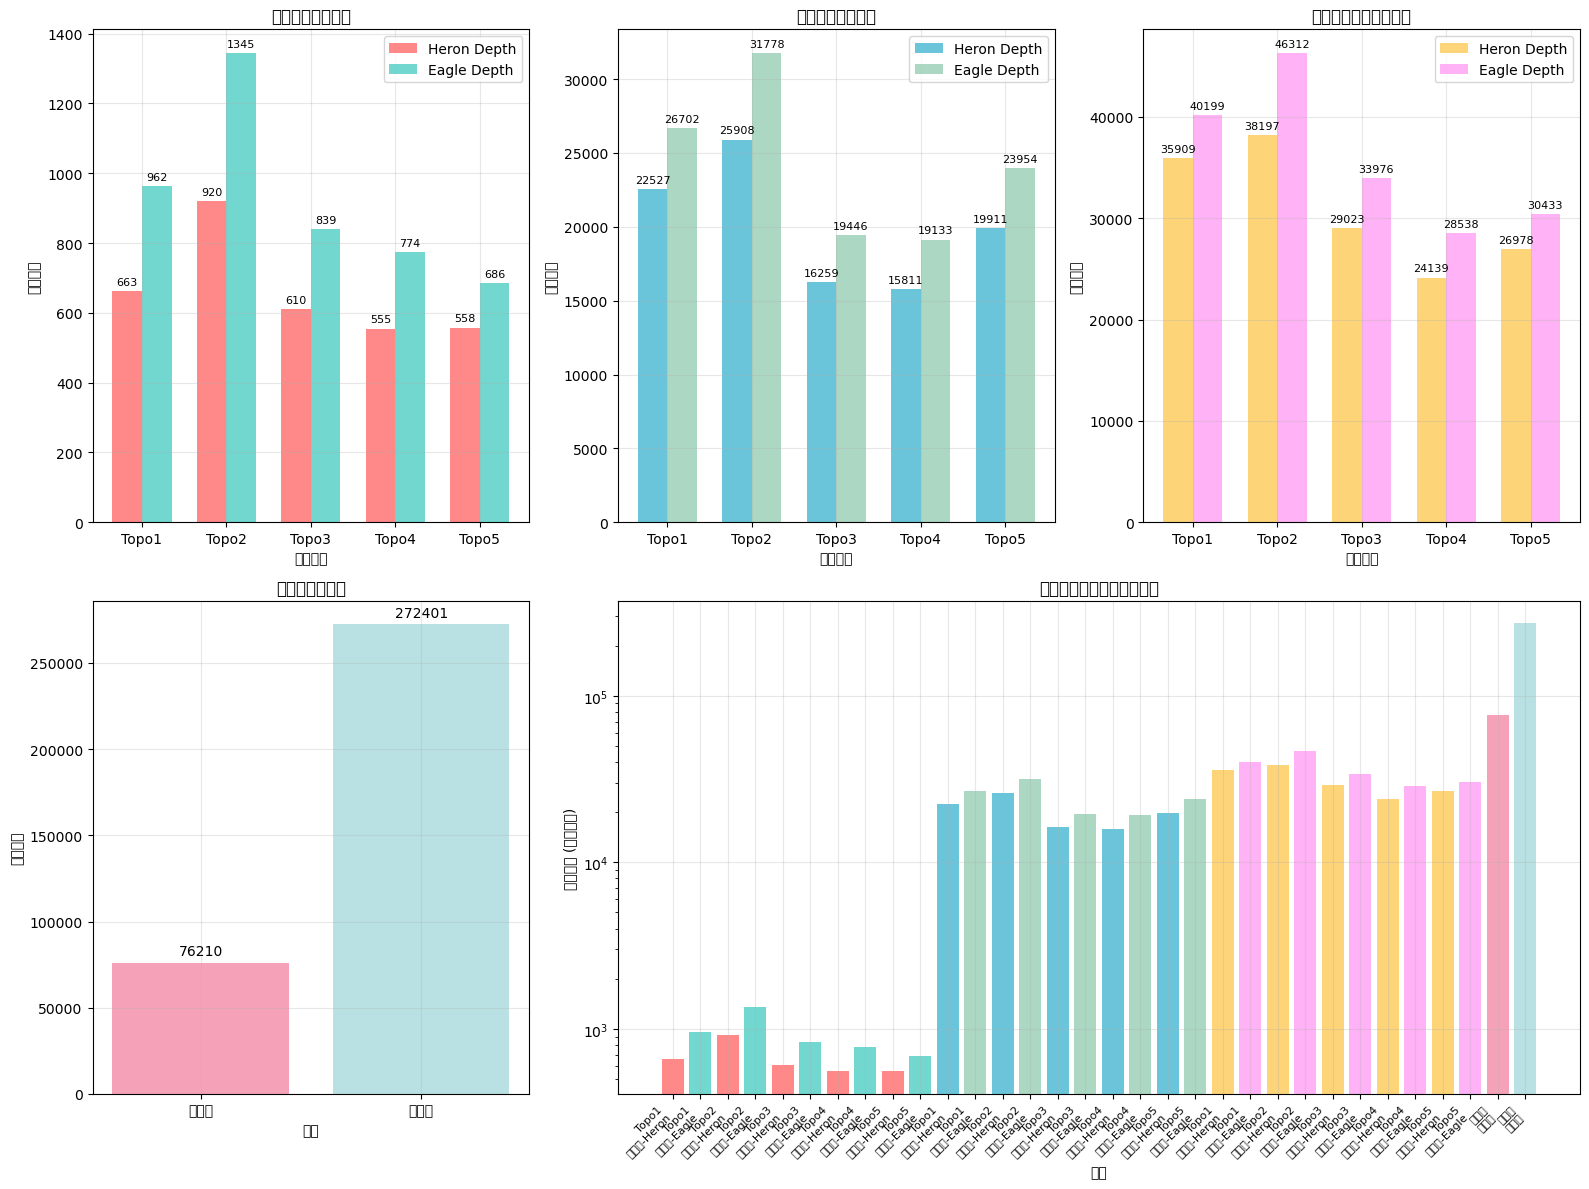

数据摘要:
转译前最大深度: 1345
第一阶最大深度: 31778
第二阶最大深度: 46312
离子阱第二阶深度是第一阶的倍数: 3.5743471985303765


In [1]:
import matplotlib.pyplot as plt
import numpy as np

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 数据准备
topologies = ['Topo1', 'Topo2', 'Topo3', 'Topo4', 'Topo5']

# Table 5.2: 转译前的电路深度
before_heron = [663, 920, 610, 555, 558]
before_eagle = [962, 1345, 839, 774, 686]

# Table 5.3: 超导体（第一阶）
super_first_heron = [22527, 25908, 16259, 15811, 19911]
super_first_eagle = [26702, 31778, 19446, 19133, 23954]

# Table 5.4: 超导体转译（第二阶）
super_second_heron = [35909, 38197, 29023, 24139, 26978]
super_second_eagle = [40199, 46312, 33976, 28538, 30433]

# Table 5.5: 离子阱转译深度
ion_trap_first = 76210
ion_trap_second = 272401

# 创建图形
fig = plt.figure(figsize=(16, 12))

# 子图1: 转译前的电路深度
ax1 = plt.subplot(2, 3, 1)
x = np.arange(len(topologies))
width = 0.35

bars1 = ax1.bar(x - width/2, before_heron, width, label='Heron Depth', 
                color='#FF6B6B', alpha=0.8)
bars2 = ax1.bar(x + width/2, before_eagle, width, label='Eagle Depth', 
                color='#4ECDC4', alpha=0.8)

ax1.set_xlabel('拓扑结构')
ax1.set_ylabel('电路深度')
ax1.set_title('转译前的电路深度')
ax1.set_xticks(x)
ax1.set_xticklabels(topologies)
ax1.legend()
ax1.grid(True, alpha=0.3)

# 在柱子上添加数值
for bar in bars1:
    height = bar.get_height()
    ax1.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

for bar in bars2:
    height = bar.get_height()
    ax1.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

# 子图2: 超导体（第一阶）
ax2 = plt.subplot(2, 3, 2)
bars3 = ax2.bar(x - width/2, super_first_heron, width, label='Heron Depth', 
                color='#45B7D1', alpha=0.8)
bars4 = ax2.bar(x + width/2, super_first_eagle, width, label='Eagle Depth', 
                color='#96CEB4', alpha=0.8)

ax2.set_xlabel('拓扑结构')
ax2.set_ylabel('电路深度')
ax2.set_title('超导体（第一阶）')
ax2.set_xticks(x)
ax2.set_xticklabels(topologies)
ax2.legend()
ax2.grid(True, alpha=0.3)

# 添加数值标签
for bar in bars3:
    height = bar.get_height()
    ax2.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

for bar in bars4:
    height = bar.get_height()
    ax2.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

# 子图3: 超导体转译（第二阶）
ax3 = plt.subplot(2, 3, 3)
bars5 = ax3.bar(x - width/2, super_second_heron, width, label='Heron Depth', 
                color='#FECA57', alpha=0.8)
bars6 = ax3.bar(x + width/2, super_second_eagle, width, label='Eagle Depth', 
                color='#FF9FF3', alpha=0.8)

ax3.set_xlabel('拓扑结构')
ax3.set_ylabel('电路深度')
ax3.set_title('超导体转译（第二阶）')
ax3.set_xticks(x)
ax3.set_xticklabels(topologies)
ax3.legend()
ax3.grid(True, alpha=0.3)

# 添加数值标签
for bar in bars5:
    height = bar.get_height()
    ax3.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

for bar in bars6:
    height = bar.get_height()
    ax3.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

# 子图4: 离子阱转译深度
ax4 = plt.subplot(2, 3, 4)
ion_settings = ['第一阶', '第二阶']
ion_depths = [ion_trap_first, ion_trap_second]
colors = ['#F38BA8', '#A8DADC']

bars7 = ax4.bar(ion_settings, ion_depths, color=colors, alpha=0.8)
ax4.set_xlabel('设置')
ax4.set_ylabel('转译深度')
ax4.set_title('离子阱转译深度')
ax4.grid(True, alpha=0.3)

# 添加数值标签
for i, bar in enumerate(bars7):
    height = bar.get_height()
    ax4.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

# 子图5: 所有数据的综合比较（对数刻度）
ax5 = plt.subplot(2, 3, (5, 6))

# 准备所有数据进行比较
all_categories = []
all_values = []
all_colors = []

# 转译前数据
for i, topo in enumerate(topologies):
    all_categories.append(f'{topo}\n转译前-Heron')
    all_values.append(before_heron[i])
    all_colors.append('#FF6B6B')
    
    all_categories.append(f'{topo}\n转译前-Eagle')
    all_values.append(before_eagle[i])
    all_colors.append('#4ECDC4')

# 第一阶数据
for i, topo in enumerate(topologies):
    all_categories.append(f'{topo}\n第一阶-Heron')
    all_values.append(super_first_heron[i])
    all_colors.append('#45B7D1')
    
    all_categories.append(f'{topo}\n第一阶-Eagle')
    all_values.append(super_first_eagle[i])
    all_colors.append('#96CEB4')

# 第二阶数据
for i, topo in enumerate(topologies):
    all_categories.append(f'{topo}\n第二阶-Heron')
    all_values.append(super_second_heron[i])
    all_colors.append('#FECA57')
    
    all_categories.append(f'{topo}\n第二阶-Eagle')
    all_values.append(super_second_eagle[i])
    all_colors.append('#FF9FF3')

# 离子阱数据
all_categories.extend(['离子阱\n第一阶', '离子阱\n第二阶'])
all_values.extend([ion_trap_first, ion_trap_second])
all_colors.extend(['#F38BA8', '#A8DADC'])

bars8 = ax5.bar(range(len(all_values)), all_values, color=all_colors, alpha=0.8)
ax5.set_xlabel('类别')
ax5.set_ylabel('电路深度 (对数刻度)')
ax5.set_title('所有电路深度数据综合比较')
ax5.set_yscale('log')
ax5.set_xticks(range(len(all_categories)))
ax5.set_xticklabels(all_categories, rotation=45, ha='right', fontsize=8)
ax5.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 打印数据摘要
print("数据摘要:")
print("="*50)
print("转译前最大深度:", max(max(before_heron), max(before_eagle)))
print("第一阶最大深度:", max(max(super_first_heron), max(super_first_eagle)))
print("第二阶最大深度:", max(max(super_second_heron), max(super_second_eagle)))
print("离子阱第二阶深度是第一阶的倍数:", ion_trap_second / ion_trap_first)

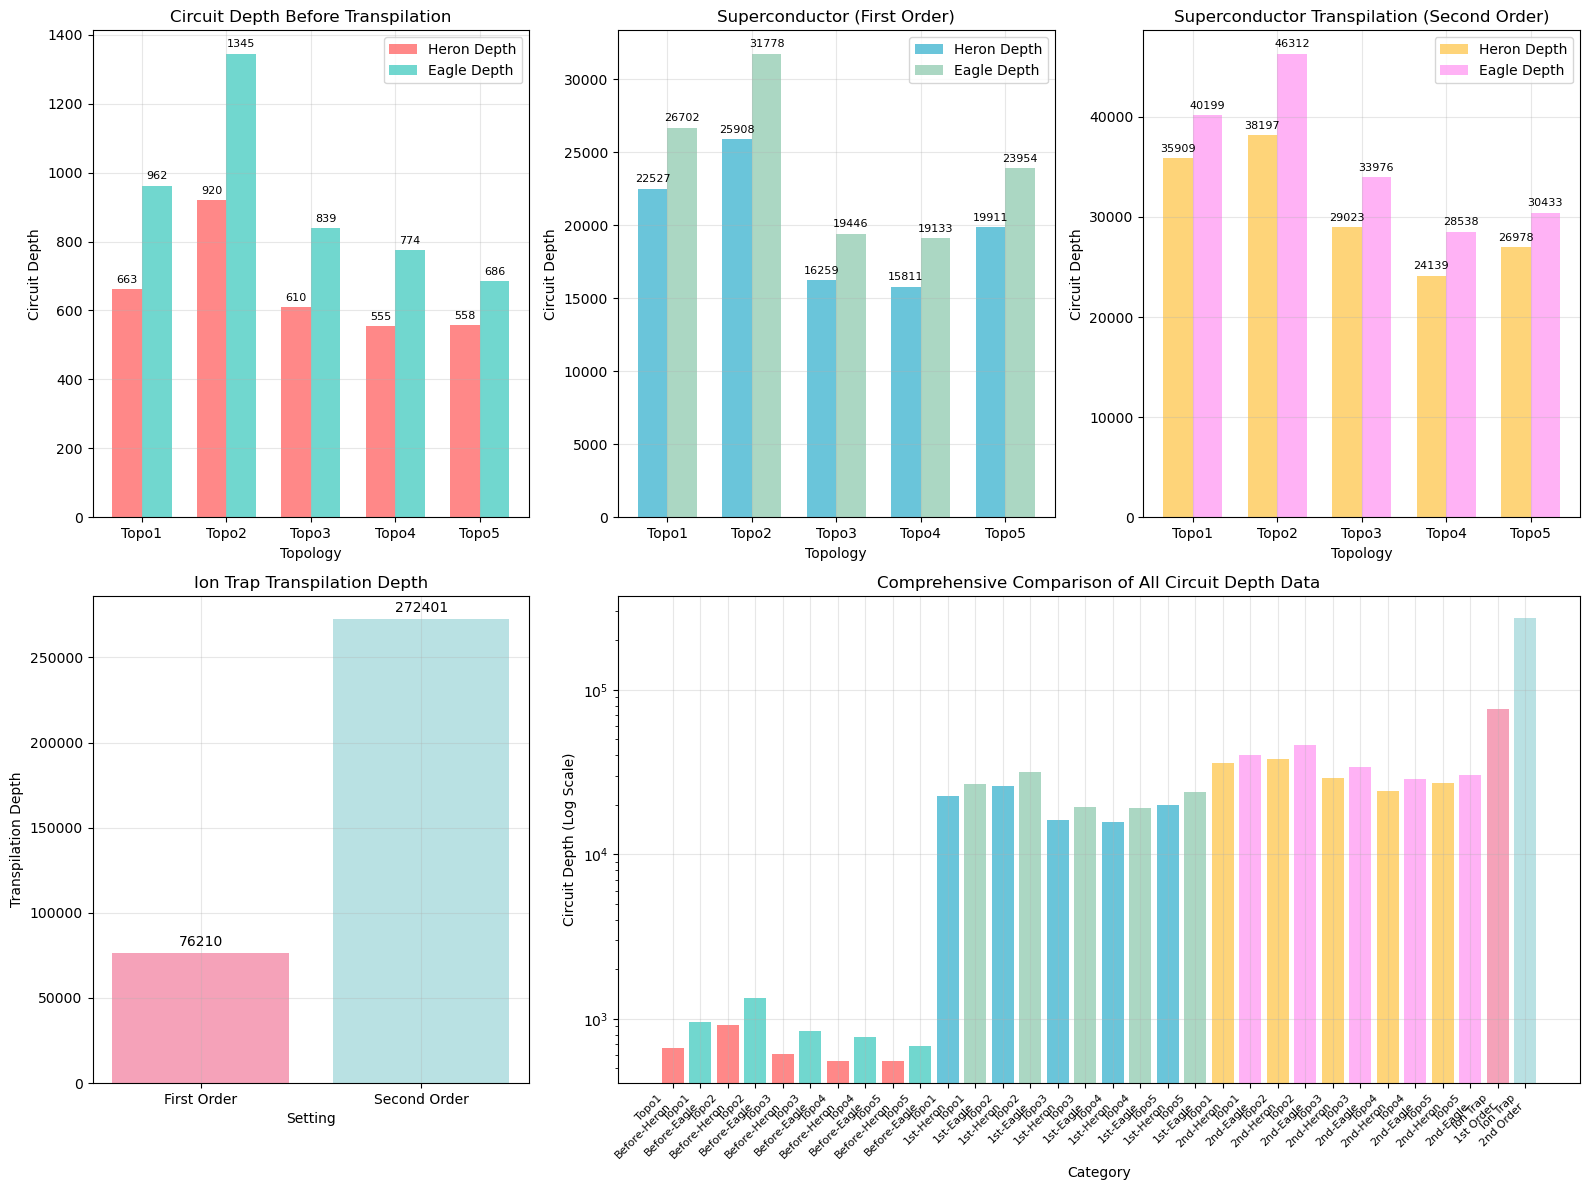

Data Summary:
Max depth before transpilation: 1345
Max depth first order: 31778
Max depth second order: 46312
Ion trap 2nd order is 3.5743471985303765 times the 1st order


In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Set font properties
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# Data preparation
topologies = ['Topo1', 'Topo2', 'Topo3', 'Topo4', 'Topo5']

# Table 5.2: 转译前的电路深度
before_heron = [663, 920, 610, 555, 558]
before_eagle = [962, 1345, 839, 774, 686]

# Table 5.3: 超导体（第一阶）
super_first_heron = [22527, 25908, 16259, 15811, 19911]
super_first_eagle = [26702, 31778, 19446, 19133, 23954]

# Table 5.4: 超导体转译（第二阶）
super_second_heron = [35909, 38197, 29023, 24139, 26978]
super_second_eagle = [40199, 46312, 33976, 28538, 30433]

# Table 5.5: 离子阱转译深度
ion_trap_first = 76210
ion_trap_second = 272401

# Create figure
fig = plt.figure(figsize=(16, 12))

# Subplot 1: Circuit depth before transpilation
ax1 = plt.subplot(2, 3, 1)
x = np.arange(len(topologies))
width = 0.35

bars1 = ax1.bar(x - width/2, before_heron, width, label='Heron Depth', 
                color='#FF6B6B', alpha=0.8)
bars2 = ax1.bar(x + width/2, before_eagle, width, label='Eagle Depth', 
                color='#4ECDC4', alpha=0.8)

ax1.set_xlabel('Topology')
ax1.set_ylabel('Circuit Depth')
ax1.set_title('Circuit Depth Before Transpilation')
ax1.set_xticks(x)
ax1.set_xticklabels(topologies)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax1.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

for bar in bars2:
    height = bar.get_height()
    ax1.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

# Subplot 2: Superconductor (first order)
ax2 = plt.subplot(2, 3, 2)
bars3 = ax2.bar(x - width/2, super_first_heron, width, label='Heron Depth', 
                color='#45B7D1', alpha=0.8)
bars4 = ax2.bar(x + width/2, super_first_eagle, width, label='Eagle Depth', 
                color='#96CEB4', alpha=0.8)

ax2.set_xlabel('Topology')
ax2.set_ylabel('Circuit Depth')
ax2.set_title('Superconductor (First Order)')
ax2.set_xticks(x)
ax2.set_xticklabels(topologies)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Add value labels
for bar in bars3:
    height = bar.get_height()
    ax2.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

for bar in bars4:
    height = bar.get_height()
    ax2.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

# Subplot 3: Superconductor transpilation (second order)
ax3 = plt.subplot(2, 3, 3)
bars5 = ax3.bar(x - width/2, super_second_heron, width, label='Heron Depth', 
                color='#FECA57', alpha=0.8)
bars6 = ax3.bar(x + width/2, super_second_eagle, width, label='Eagle Depth', 
                color='#FF9FF3', alpha=0.8)

ax3.set_xlabel('Topology')
ax3.set_ylabel('Circuit Depth')
ax3.set_title('Superconductor Transpilation (Second Order)')
ax3.set_xticks(x)
ax3.set_xticklabels(topologies)
ax3.legend()
ax3.grid(True, alpha=0.3)

# Add value labels
for bar in bars5:
    height = bar.get_height()
    ax3.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

for bar in bars6:
    height = bar.get_height()
    ax3.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

# Subplot 4: Ion trap transpilation depth
ax4 = plt.subplot(2, 3, 4)
ion_settings = ['First Order', 'Second Order']
ion_depths = [ion_trap_first, ion_trap_second]
colors = ['#F38BA8', '#A8DADC']

bars7 = ax4.bar(ion_settings, ion_depths, color=colors, alpha=0.8)
ax4.set_xlabel('Setting')
ax4.set_ylabel('Transpilation Depth')
ax4.set_title('Ion Trap Transpilation Depth')
ax4.grid(True, alpha=0.3)

# Add value labels
for i, bar in enumerate(bars7):
    height = bar.get_height()
    ax4.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

# Subplot 5: Comprehensive comparison of all data (log scale)
ax5 = plt.subplot(2, 3, (5, 6))

# Prepare all data for comparison
all_categories = []
all_values = []
all_colors = []

# Before transpilation data
for i, topo in enumerate(topologies):
    all_categories.append(f'{topo}\nBefore-Heron')
    all_values.append(before_heron[i])
    all_colors.append('#FF6B6B')
    
    all_categories.append(f'{topo}\nBefore-Eagle')
    all_values.append(before_eagle[i])
    all_colors.append('#4ECDC4')

# First order data
for i, topo in enumerate(topologies):
    all_categories.append(f'{topo}\n1st-Heron')
    all_values.append(super_first_heron[i])
    all_colors.append('#45B7D1')
    
    all_categories.append(f'{topo}\n1st-Eagle')
    all_values.append(super_first_eagle[i])
    all_colors.append('#96CEB4')

# Second order data
for i, topo in enumerate(topologies):
    all_categories.append(f'{topo}\n2nd-Heron')
    all_values.append(super_second_heron[i])
    all_colors.append('#FECA57')
    
    all_categories.append(f'{topo}\n2nd-Eagle')
    all_values.append(super_second_eagle[i])
    all_colors.append('#FF9FF3')

# Ion trap data
all_categories.extend(['Ion Trap\n1st Order', 'Ion Trap\n2nd Order'])
all_values.extend([ion_trap_first, ion_trap_second])
all_colors.extend(['#F38BA8', '#A8DADC'])

bars8 = ax5.bar(range(len(all_values)), all_values, color=all_colors, alpha=0.8)
ax5.set_xlabel('Category')
ax5.set_ylabel('Circuit Depth (Log Scale)')
ax5.set_title('Comprehensive Comparison of All Circuit Depth Data')
ax5.set_yscale('log')
ax5.set_xticks(range(len(all_categories)))
ax5.set_xticklabels(all_categories, rotation=45, ha='right', fontsize=8)
ax5.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print data summary
print("Data Summary:")
print("="*50)
print("Max depth before transpilation:", max(max(before_heron), max(before_eagle)))
print("Max depth first order:", max(max(super_first_heron), max(super_first_eagle)))
print("Max depth second order:", max(max(super_second_heron), max(super_second_eagle)))
print("Ion trap 2nd order is", ion_trap_second / ion_trap_first, "times the 1st order")

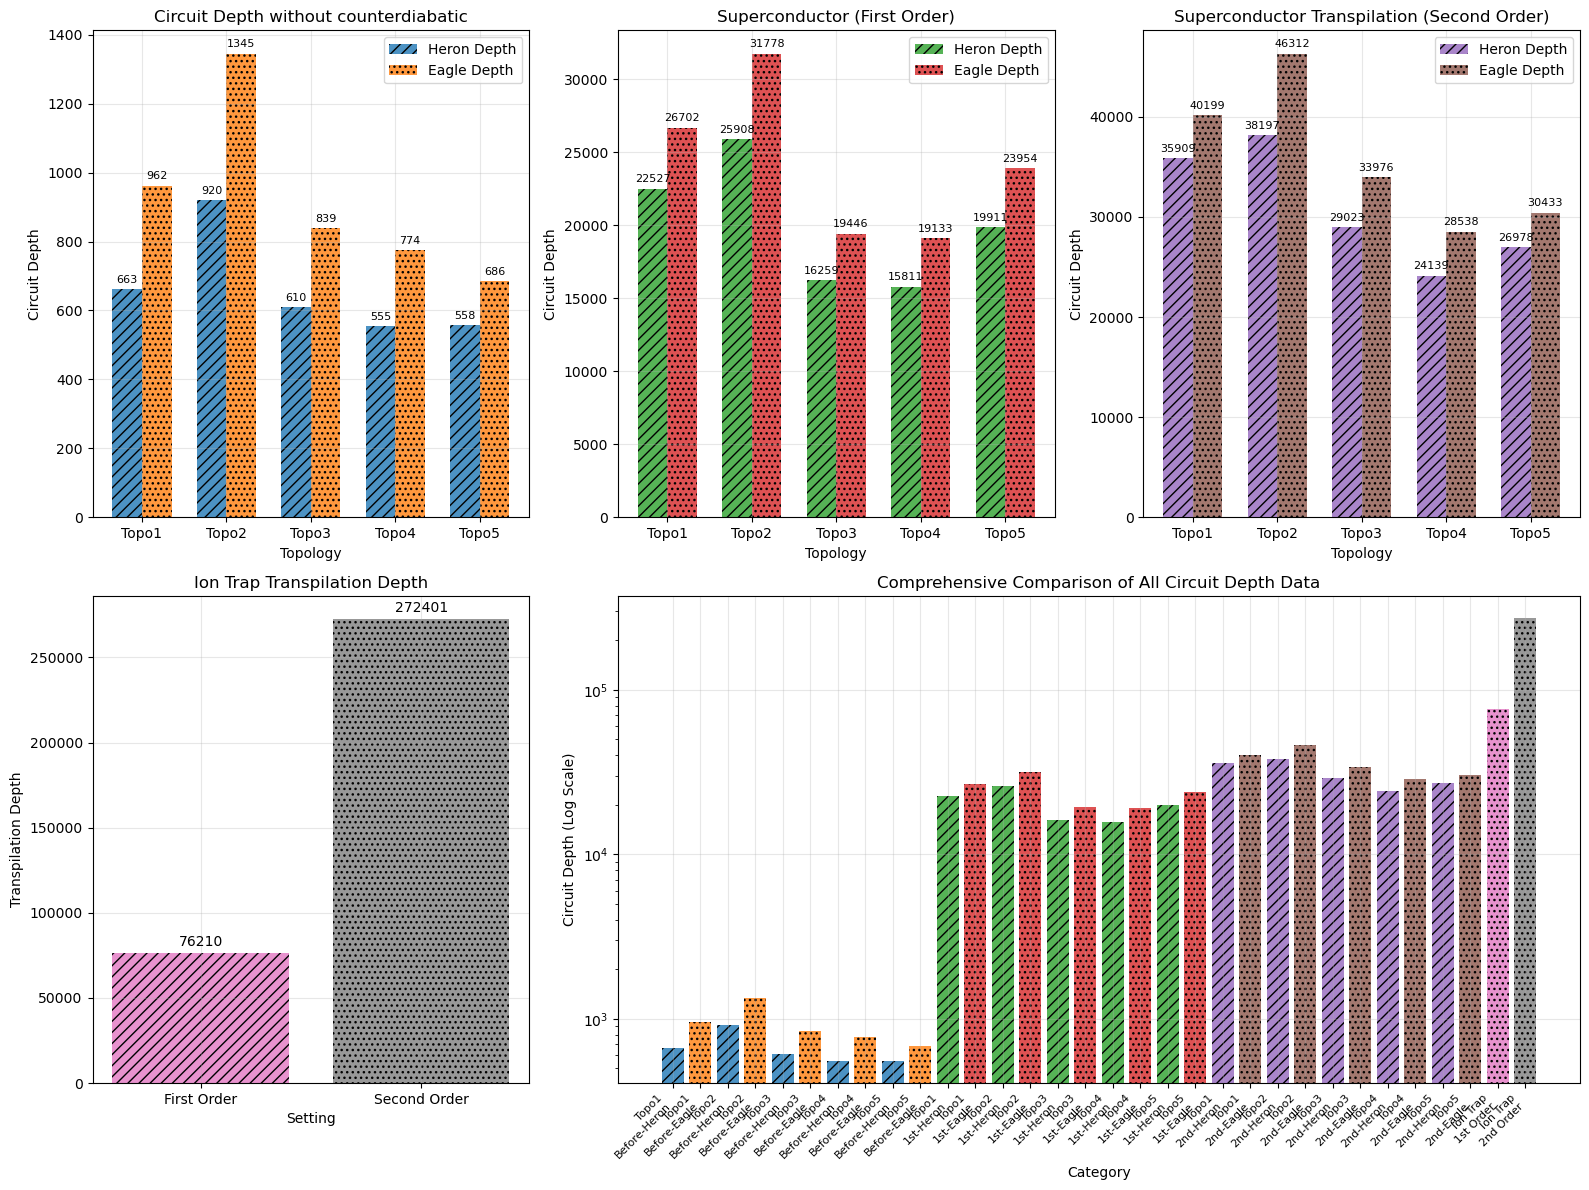

Data Summary:
Max depth before transpilation: 1345
Max depth first order: 31778
Max depth second order: 46312
Ion trap 2nd order is 3.5743471985303765 times the 1st order


In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Set font properties
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# Data preparation
topologies = ['Topo1', 'Topo2', 'Topo3', 'Topo4', 'Topo5']

# Table 5.2: 转译前的电路深度
before_heron = [663, 920, 610, 555, 558]
before_eagle = [962, 1345, 839, 774, 686]

# Table 5.3: 超导体（第一阶）
super_first_heron = [22527, 25908, 16259, 15811, 19911]
super_first_eagle = [26702, 31778, 19446, 19133, 23954]

# Table 5.4: 超导体转译（第二阶）
super_second_heron = [35909, 38197, 29023, 24139, 26978]
super_second_eagle = [40199, 46312, 33976, 28538, 30433]

# Table 5.5: 离子阱转译深度
ion_trap_first = 76210
ion_trap_second = 272401

# Create figure
fig = plt.figure(figsize=(16, 12))

# Subplot 1: Circuit depth before transpilation
ax1 = plt.subplot(2, 3, 1)
x = np.arange(len(topologies))
width = 0.35

bars1 = ax1.bar(x - width/2, before_heron, width, label='Heron Depth', 
                color='#1f77b4', alpha=0.8, hatch='///')
bars2 = ax1.bar(x + width/2, before_eagle, width, label='Eagle Depth', 
                color='#ff7f0e', alpha=0.8, hatch='...')

ax1.set_xlabel('Topology')
ax1.set_ylabel('Circuit Depth')
ax1.set_title('Circuit Depth without counterdiabatic')
ax1.set_xticks(x)
ax1.set_xticklabels(topologies)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax1.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

for bar in bars2:
    height = bar.get_height()
    ax1.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

# Subplot 2: Superconductor (first order)
ax2 = plt.subplot(2, 3, 2)
bars3 = ax2.bar(x - width/2, super_first_heron, width, label='Heron Depth', 
                color='#2ca02c', alpha=0.8, hatch='///')
bars4 = ax2.bar(x + width/2, super_first_eagle, width, label='Eagle Depth', 
                color='#d62728', alpha=0.8, hatch='...')

ax2.set_xlabel('Topology')
ax2.set_ylabel('Circuit Depth')
ax2.set_title('Superconductor (First Order)')
ax2.set_xticks(x)
ax2.set_xticklabels(topologies)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Add value labels
for bar in bars3:
    height = bar.get_height()
    ax2.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

for bar in bars4:
    height = bar.get_height()
    ax2.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

# Subplot 3: Superconductor transpilation (second order)
ax3 = plt.subplot(2, 3, 3)
bars5 = ax3.bar(x - width/2, super_second_heron, width, label='Heron Depth', 
                color='#9467bd', alpha=0.8, hatch='///')
bars6 = ax3.bar(x + width/2, super_second_eagle, width, label='Eagle Depth', 
                color='#8c564b', alpha=0.8, hatch='...')

ax3.set_xlabel('Topology')
ax3.set_ylabel('Circuit Depth')
ax3.set_title('Superconductor Transpilation (Second Order)')
ax3.set_xticks(x)
ax3.set_xticklabels(topologies)
ax3.legend()
ax3.grid(True, alpha=0.3)

# Add value labels
for bar in bars5:
    height = bar.get_height()
    ax3.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

for bar in bars6:
    height = bar.get_height()
    ax3.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

# Subplot 4: Ion trap transpilation depth
ax4 = plt.subplot(2, 3, 4)
ion_settings = ['First Order', 'Second Order']
ion_depths = [ion_trap_first, ion_trap_second]
colors = ['#e377c2', '#7f7f7f']
hatches = ['///', '...']

bars7 = ax4.bar(ion_settings, ion_depths, color=colors, alpha=0.8, hatch=hatches)
ax4.set_xlabel('Setting')
ax4.set_ylabel('Transpilation Depth')
ax4.set_title('Ion Trap Transpilation Depth')
ax4.grid(True, alpha=0.3)

# Add value labels
for i, bar in enumerate(bars7):
    height = bar.get_height()
    ax4.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

# Subplot 5: Comprehensive comparison of all data (log scale)
ax5 = plt.subplot(2, 3, (5, 6))

# Prepare all data for comparison
all_categories = []
all_values = []
all_colors = []

# Before transpilation data
for i, topo in enumerate(topologies):
    all_categories.append(f'{topo}\nBefore-Heron')
    all_values.append(before_heron[i])
    all_colors.append('#1f77b4')
    
    all_categories.append(f'{topo}\nBefore-Eagle')
    all_values.append(before_eagle[i])
    all_colors.append('#ff7f0e')

# First order data
for i, topo in enumerate(topologies):
    all_categories.append(f'{topo}\n1st-Heron')
    all_values.append(super_first_heron[i])
    all_colors.append('#2ca02c')
    
    all_categories.append(f'{topo}\n1st-Eagle')
    all_values.append(super_first_eagle[i])
    all_colors.append('#d62728')

# Second order data
for i, topo in enumerate(topologies):
    all_categories.append(f'{topo}\n2nd-Heron')
    all_values.append(super_second_heron[i])
    all_colors.append('#9467bd')
    
    all_categories.append(f'{topo}\n2nd-Eagle')
    all_values.append(super_second_eagle[i])
    all_colors.append('#8c564b')

# Ion trap data
all_categories.extend(['Ion Trap\n1st Order', 'Ion Trap\n2nd Order'])
all_values.extend([ion_trap_first, ion_trap_second])
all_colors.extend(['#e377c2', '#7f7f7f'])

bars8 = ax5.bar(range(len(all_values)), all_values, color=all_colors, alpha=0.8)

# Add hatching patterns for better accessibility
hatching_patterns = []
for i in range(len(all_values)):
    if 'Heron' in all_categories[i]:
        hatching_patterns.append('///')
    else:
        hatching_patterns.append('...')

# Apply hatching patterns
for i, bar in enumerate(bars8):
    bar.set_hatch(hatching_patterns[i])

ax5.set_xlabel('Category')
ax5.set_ylabel('Circuit Depth (Log Scale)')
ax5.set_title('Comprehensive Comparison of All Circuit Depth Data')
ax5.set_yscale('log')
ax5.set_xticks(range(len(all_categories)))
ax5.set_xticklabels(all_categories, rotation=45, ha='right', fontsize=8)
ax5.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print data summary
print("Data Summary:")
print("="*50)
print("Max depth before transpilation:", max(max(before_heron), max(before_eagle)))
print("Max depth first order:", max(max(super_first_heron), max(super_first_eagle)))
print("Max depth second order:", max(max(super_second_heron), max(super_second_eagle)))
print("Ion trap 2nd order is", ion_trap_second / ion_trap_first, "times the 1st order")